In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

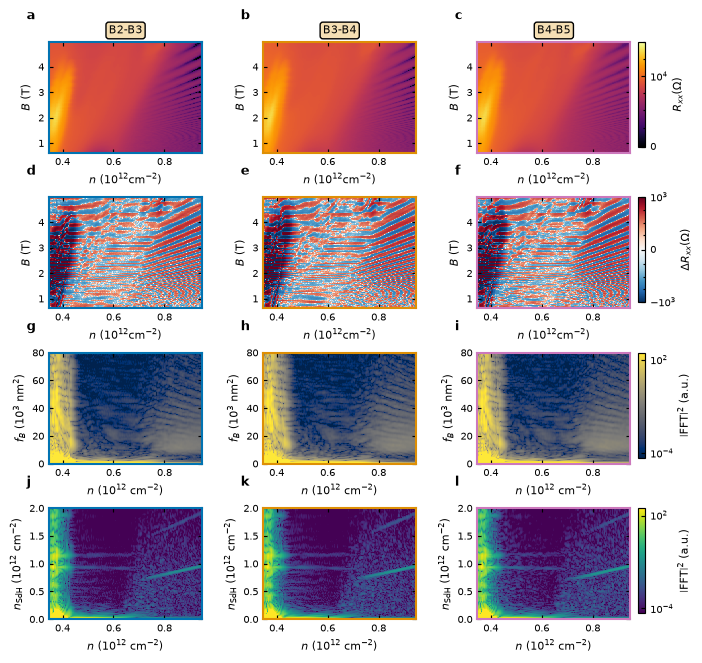

In [2]:
fig = plt.figure(figsize=(7.5, 7.5))
gs = GridSpec(4, 3, wspace=0.4, hspace=0.4)


raw_axes = [plt.subplot(gs[0, i]) for i in range(3)]
bgsub_axes = [plt.subplot(gs[1, i]) for i in range(3)]
B_axes = [plt.subplot(gs[2, i]) for i in range(3)]
Binv_axes = [plt.subplot(gs[3, i]) for i in range(3)]

contact_names = {
    1: "B2-B3", 
    2: "B3-B4", 
    3: "B4-B5"
}
label_spacer = 0.03

# analyzer = Lf_analysis(1840, contact=2)
letters = list(map(chr, range(97, 97+12)))

no_detrend = lambda y, x: (x,0)

for i, (contact_name, contact_color) in enumerate(contact_colors.items()):
    analyzer = Lf_analysis(1840, contact=i+1)
    
    #### Raw LF ####
    ax = raw_axes[i]
    norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6) 
    plot = analyzer.plot_lf(fig, ax, norm,
        bg_method=no_detrend, # No subtraction,                         
        bg_method_params= {}, 
        blims=(0.62, 4.98),
        cmap='inferno'
    )
    ax.set_title(
        contact_names[i+1],
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#f5dfb4",
            edgecolor="k",
            linewidth=1,
            alpha=1,
        )  
    )
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i], fontweight='bold')
    if i == 2:
        cb_width = 0.3 * 3.5/7.5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax, ticks =[0, 1e4], \
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
        cb.ax.set_ylabel(r'$R_{xx} (\Omega)$', labelpad=3)

    #### BG subtracted ####
    ax = bgsub_axes[i]
    norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
    plot = analyzer.plot_lf(fig, ax, norm,
        bg_method=detrend_butterworth,                    
        bg_method_params= {'cutoff': None, 'order': 4},
        # bg_method=detrend_savgol,
        # bg_method_params={'win':101, 'poly':3, 'max_win_frac':0.4},
        blims=(0.62, 4.98),
        cmap='RdBu_r'
    )
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+3], fontweight='bold')
    if i == 2:
        cb_width = 0.3 * 3.5/7.5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax, ticks = [-1e3, 0, 1e3], \
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.4)
        cb.ax.set_ylabel(r'$\Delta R_{xx} (\Omega)$', labelpad=3)
    
    #### FFT in B ####
    ax = B_axes[i] 
    # norm = colors.LogNorm(vmin=1e3, vmax=1e10)

    plot = analyzer.plot_fft_B(fig, ax, norm_psd,
        bg_method=no_detrend,                    
        bg_method_params= {},
        padding=8,
        blims=(0.62, 4.98),
    )
    ax.set_ylim(0,80)
    # ax.set_ylim(0,1)
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+6], fontweight='bold')
    if i == 2:
        cb_width = 0.3 * 3.5/7.5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax, ticks = [1e-4, 1e2], \
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.4)
        cb.ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=3)
    
    #### FFT in 1/B ####
    ax = Binv_axes[i] 
    # norm = colors.LogNorm(vmin=1e5, vmax=1e12)

    plot = analyzer.plot_fft_invcm(fig, ax, norm_psd,
        bg_method=no_detrend,                    
        bg_method_params= {},
        padding=8,
        blims=(0.62, 4.98),
    )
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+9], fontweight='bold')
    if i == 2:
        cb_width = 0.3 * 3.5/7.5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax, ticks =[1e-4, 1e2],\
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.4)
        cb.ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=3)

    for j, ax in enumerate((raw_axes[i], bgsub_axes[i], B_axes[i], Binv_axes[i])):
        for spine in ax.spines.values():
            spine.set_edgecolor(contact_color)
            spine.set_linewidth(1.5)
        # if i != 0:
        #     ax.set_ylabel('')
        # if j != 3:
        #     ax.set_xlabel('')

    
plt.savefig('figS_FFT_contact_comp.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)